# Business and data understanding.

This notebook defines the bussines objectives, the success criteria and data exploration.

## Business understanding.

**Objective:** 
Predict the closing price of Apple (AAPL) for the next trading day.

**Success criteria:** 
Model metrics on the test set are better than the baseline.
The baseline is defined as a one day lag prediction where the next day close is same then previous closing day.
The metrics used to compare the model against the baseline are Root Mean Square Error `RMSE` and Mean Directional Accuracy `MDA`, to ensure not only the error is lower but moves in the correct direction (up/down).

| Metric | Success Criteria |
|---|---|
| `RMSE` | Model < Baseline |
| `MDA` | Model > Baseline |


## Data understanding.

The dataset includes stock prices for all companies in the S&P 500 index, the dataset is updated daily and is available at Kaggle as a public domain.

Yash. 2026. *S&P500 All Assets – Daily Updated Dataset*. Kaggle.  
https://www.kaggle.com/datasets/yash16jr/s-and-p500-daily-update-dataset/data

In this section we do an exploratory data study to discover data problems early before we move to the next stage, at the same time we gain some insights to visualize what to expect from the data, how the stock price moves over time, this exploration can provide some direction on how to better prepare the data for modeling and what to expect from the model predictions.

The dataset is located at `data/SnP_daily_update.csv/`


### Setup

In [8]:
""" Notebook setup to make the project's modules importable. """

import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if "TF_CPP_MIN_LOG_LEVEL" not in os.environ:
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide TensorFlow info/warning logs

In [23]:
""" Plot are defined in a plotting module for a consistent style """
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src import plotting

plotting.set_plot_style()
pd.set_option("display.width", 120)


## Load the dataset.


In [24]:
""" Load the dataset from csv file """
df = pd.read_csv(config.DATA_PATH, low_memory=False)
df.head()

,Price,Close,Close.1,Close.2,Close.3,Close.4,Close.5,Close.6,Close.7,Close.8,...,Volume.493,Volume.494,Volume.495,Volume.496,Volume.497,Volume.498,Volume.499,Volume.500,Volume.501,Volume.502
0,Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,19.772951126098633,6.400959491729736,NaN,NaN,18.078800201416016,7.60190486907959,30.8563289642334,37.09000015258789,21.703716278076172,...,1832400,4741400,2670400,27809100,NaN,NaN,2962274,805872,168800,NaN
3,2010-01-05,19.55817413330078,6.4120259284973145,NaN,NaN,17.9327335357666,7.5765485763549805,31.047039031982422,37.70000076293945,21.669450759887695,...,1724500,5644300,4321400,30174700,NaN,NaN,3298757,1769643,168800,NaN
4,2010-01-06,19.488679885864258,6.31003475189209,NaN,NaN,18.032329559326172,7.543794631958008,31.37708282470703,37.619998931884766,21.628334045410156,...,2254400,2738800,2164500,35044700,NaN,NaN,4178981,1315619,385300,NaN


#### The csv file has the following structure:
- The first two rows are column headers.
    - The first column header includes `Close`, `High`, `Low`, `Open`, `Volume`.
    - The second column header includes the ticker names like `AAPL` or `AMZN`.
    - The third row is empty.
- The first column is the Date index.

To properly load this dataset we are combining the two column headers into a hierarchical index using pandas `MultiIndex` object.

Reference:
https://pandas.pydata.org/pandas-docs/stable/user_guide/advanced.html

In [ ]:
""" Load the dataset with hierarchical indexing """

df = pd.read_csv(
    config.DATA_PATH,
    header=[0, 1],      # first two rows are headers
    skiprows=[2],       # skip the empty third row
    index_col=0,        # first column is the Date
    parse_dates=True    # convert Date to datetime
)

print(df)


Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
2010-01-04   19.772951    6.400959         NaN         NaN   18.078800   
2010-01-05   19.558174    6.412026         NaN         NaN   17.932734   
2010-01-06   19.488680    6.310035         NaN         NaN   18.032330   
2010-01-07   19.463402    6.298369         NaN         NaN   18.181709   
2010-01-08   19.457092    6.340242         NaN         NaN   18.274660   
...                ...         ...         ...         ...         ...   
2026-09-14  146.800003  333.079987  261.769989  170.649994  103.089996   
2026-09-15  150.270004  331.339996  263.040009  168.320007  102.029999   
2026-09-16  153.690002  332.410004  262.510010  167.509995  102.360001   
2026-09-17  156.339996  337.000000  264.019989  165.929993  102.230003   
2026-09-18  156.470001  336.130005  263.959991  166.220001  102.610001   

Price                                

### MultiIndex Access Quick Reference
The following table shows some ways to access data subsets using `MultiIndex':

| Goal | Code Example | Result |
|------|--------------|--------|
| Get AAPL Close | `df['Close', 'AAPL']` | Series of AAPL Close prices |
| Get all Close columns | `df['Close']` | DataFrame of Close for all tickers |
| Get all fields for AAPL | `df.xs('AAPL', level=1, axis=1)` | Close/High/Low/Open/Volume for AAPL |
| Get Close for AAPL & META | `df.loc[:, ('Close', ['AAPL', 'META'])]` | Close subset for selected tickers |
| Get all tickers for Close & High | `df[['Close', 'High']]` | Multi-field subset |
| Get AAPL + related tickers (AAPL, GOOG, MSFT) | `df.loc[:, (slice(None), ['AAPL','GOOG','MSFT'])]` | All fields for selected tickers |
| Get a date range for AAPL | `df.loc['2010-01-01':'2010-01-10', (slice(None), 'AAPL')]` | AAPL panel over date range |
| Get specific date + field | `df.loc['2010-01-04', ('Close','AAPL')]` | Single value |
| Get Close for all tickers on a date | `df.loc['2010-01-04', 'Close']` | Row of Close values |
| Get all fields for AAPL & AMZN | `df.loc[:, (slice(None), ['AAPL','AMZN'])]` | Multi-field, multi-ticker panel |


## Data Exploration.

#### To data exploration focus on Apple stiker AAPL.

In [14]:
""" Get a cross-section of the dataset with only Apple data """

apple_df = df.xs('AAPL', level=1, axis=1)
print("shape (rows, columns):", apple_df.shape)

shape (rows, columns): (4203, 5)


In [ ]:
""" Get dataset information """
apple_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4203 entries, 2010-01-04 to 2026-09-18
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4203 non-null   float64
 1   High    4203 non-null   float64
 2   Low     4203 non-null   float64
 3   Open    4203 non-null   float64
 4   Volume  4203 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 197.0 KB


### Volume is a count of shares so it is an integer, the rest are real numbers representing the stock price.

## Data Quality

In [ ]:
""" Verify the data quality """
checks = {
    "rows": len(apple_df),
    "missing values": int(apple_df.isna().sum().sum()),
    "duplicated dates": int(apple_df.index.duplicated().sum()),
    "zero volume days": int((apple_df["Volume"] == 0).sum()),
    "rows with High < Low": int((apple_df["High"] < apple_df["Low"]).sum()),
}
display(pd.Series(checks, name="value").to_frame())
display(apple_df[apple_df["Volume"] == 0])

# Gaps between consecutive trading days. Weekends and holidays give 3-4 calendar days;
# longer gaps can mean missing data or a market closure.
gaps = apple_df.index.to_series().diff().dt.days
print("Largest gaps between rows (calendar days):")
print(gaps.sort_values(ascending=False).head(5))

,value
rows,4203
missing values,0
duplicated dates,0
zero-volume days,0
rows with High < Low,0


Price,Close,High,Low,Open,Volume


Largest gaps between rows (calendar days):
2012-10-31    5.0
2025-04-21    4.0
2021-06-01    4.0
2017-09-05    4.0
2016-03-28    4.0
dtype: float64


### The data is clean:
- No missing values.
- No duplicates.
- No zero volume days.
- No inconsistent values (High < Low).
- The longest gap was caused by hurricane Sandy on October 2012

https://www.theguardian.com/world/2012/oct/31/new-york-stock-exchange-opens-sandy


In [ ]:
""" Get basic statistics from the data """
apple_df.describe()

Price,Close,High,Low,Open,Volume
count,4203.000000,4203.000000,4203.000000,4203.000000,4.203000e+03
mean,86.239713,87.099488,85.295393,86.161036,2.117998e+08
std,84.788716,85.627460,83.848298,84.680848,2.136442e+08
min,5.744145,5.862286,5.690308,5.753714,1.791060e+07
25%,18.917126,19.022925,18.697146,18.902979,7.341500e+07
50%,40.720520,40.996762,40.451919,40.748178,1.253072e+08
75%,150.410011,151.965513,148.489408,150.111728,2.791866e+08
max,339.786926,344.273097,337.059318,339.736982,1.880998e+09


#### The data shows a maximum closing stock price of $339.79 with a minimum of $5.74 since 2010, the mean is $86 with a standard deviation of $84.79 which shows how much the stock has changed in a period of 16 years.

## Full History

To get the full price history we defined a plot function to get the price and volume of selected ticker in `config.TICKER`

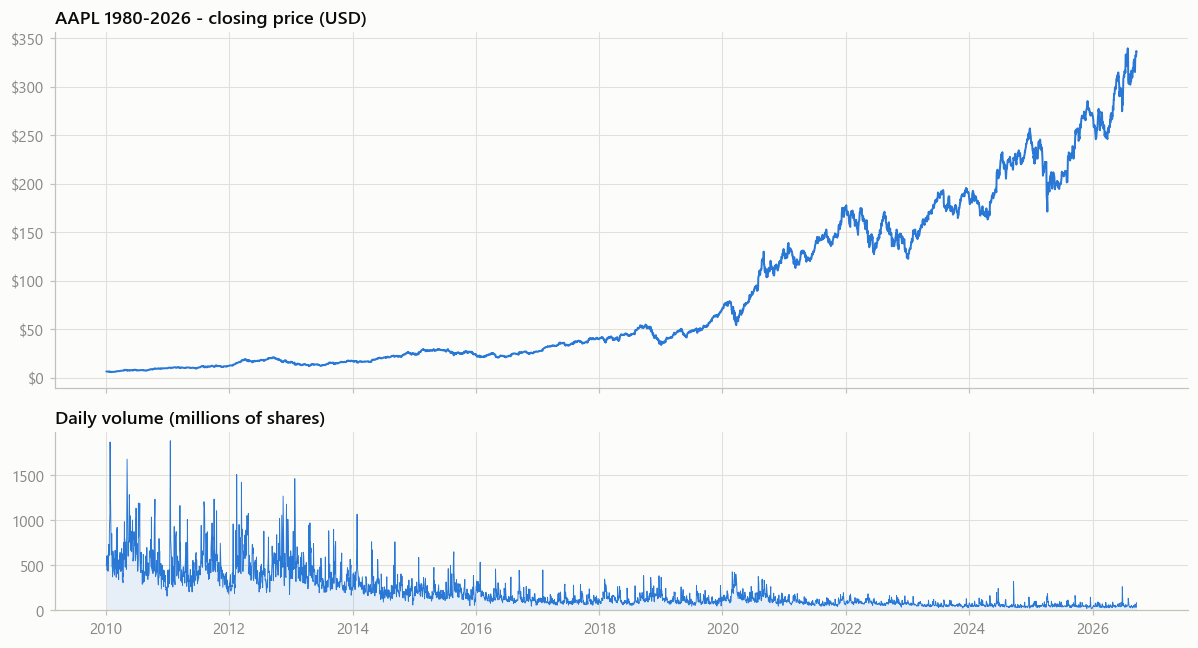

In [26]:
""" Plot the full price history """
plotting.plot_price_and_volume(apple_df, title=f"{config.TICKER} 1980-2026")
plt.show()

### The plot shows a large volume variation from 2010 to 2018 with a decreasing tendency and a steady and slow price growth before 2018, then an more pronounced price increase from $50 to $339 after 2018.



Next: [`02_data_preparation.ipynb`](02_data_preparation.ipynb)